In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import warnings

import matplotlib.font_manager as fm

# 한글 폰트 설정 (실행 환경에 따라 폰트가 다를 수 있음, 기본적으로 깨짐 방지용 설정)
try:
    font_path = r'C:\Windows\Fonts\malgun.ttf'
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
except:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('final.csv')
df.drop(['matchId','gameDuration'], axis=1, inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
blueWins,94355.0,0.463558,0.498673,0.0,0.0,0.0,1.0,1.0
blueWardsPlaced,94355.0,47.808871,39.392788,9.0,30.0,35.0,48.0,521.0
blueControlWardsPlaced,94355.0,6.943522,2.541030,0.0,5.0,7.0,9.0,25.0
blueWardsDestroyed,94355.0,9.888824,4.043725,0.0,7.0,9.0,12.0,54.0
blueControlWardsDestroyed,94355.0,4.172296,1.889871,0.0,3.0,4.0,5.0,15.0
blueFirstBlood,94355.0,0.494420,0.499972,0.0,0.0,0.0,1.0,1.0
blueKills,94355.0,12.546012,4.840475,0.0,9.0,12.0,16.0,43.0
blueDeaths,94355.0,12.680801,4.813805,0.0,9.0,12.0,16.0,41.0
blueAssists,94355.0,14.778380,6.987882,0.0,10.0,14.0,19.0,55.0
blueDragons,94355.0,0.580202,0.665081,0.0,0.0,0.0,1.0,2.0


In [4]:
print(df.columns.tolist())

['blueWins', 'blueWardsPlaced', 'blueControlWardsPlaced', 'blueWardsDestroyed', 'blueControlWardsDestroyed', 'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists', 'blueDragons', 'blueHeralds', 'blueVoidGrubs', 'blueTowersDestroyed', 'bluePlatesDestroyed', 'blueTotalGold', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueTotalJungleMinionsKilled', 'blueFirstTurret', 'blueInhibitorsDestroyed', 'blueFirstDragon', 'redWardsPlaced', 'redControlWardsPlaced', 'redWardsDestroyed', 'redControlWardsDestroyed', 'redFirstBlood', 'redKills', 'redDeaths', 'redAssists', 'redDragons', 'redHeralds', 'redVoidGrubs', 'redTowersDestroyed', 'redPlatesDestroyed', 'redTotalGold', 'redTotalExperience', 'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redFirstTurret', 'redInhibitorsDestroyed', 'redFirstDragon']


In [5]:
import pandas as pd
import numpy as np
from scipy import stats

target_vars_ordered = [
    ('성장', 'TotalGold', 'blueTotalGold', 'redTotalGold'),
    ('성장', 'TotalExperience', 'blueTotalExperience', 'redTotalExperience'),
    ('성장', 'TotalMinionsKilled', 'blueTotalMinionsKilled', 'redTotalMinionsKilled'),
    ('성장', 'TotalJungleMinionsKilled', 'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled'),
    ('전투', 'Kills', 'blueKills', 'redKills'),
    ('전투', 'Deaths', 'blueDeaths', 'redDeaths'),
    ('전투', 'Assists', 'blueAssists', 'redAssists'),
    ('전투', 'FirstBlood', 'blueFirstBlood', 'redFirstBlood'),
    ('오브젝트', 'Dragons', 'blueDragons', 'redDragons'),
    ('오브젝트', 'FirstDragon', 'blueFirstDragon', 'redFirstDragon'),
    ('오브젝트', 'Heralds', 'blueHeralds', 'redHeralds'),
    ('오브젝트', 'VoidGrubs', 'blueVoidGrubs', 'redVoidGrubs'),
    ('구조물', 'TowersDestroyed', 'blueTowersDestroyed', 'redTowersDestroyed'),
    ('구조물', 'FirstTowerDestroyed', 'blueFirstTurret', 'redFirstTurret'),
    ('구조물', 'PlatesDestroyed', 'bluePlatesDestroyed', 'redPlatesDestroyed'),
    ('구조물', 'InhibitorsDestroyed', 'blueInhibitorsDestroyed', 'redInhibitorsDestroyed'),
    ('시야', 'WardsPlaced', 'blueWardsPlaced', 'redWardsPlaced'),
    ('시야', 'ControlWardsPlaced', 'blueControlWardsPlaced', 'redControlWardsPlaced'),
    ('시야', 'WardsDestroyed', 'blueWardsDestroyed', 'redWardsDestroyed'),
    ('시야', 'ControlWardsDestroyed', 'blueControlWardsDestroyed', 'redControlWardsDestroyed') 
]

results = []

for category, name, b_col, r_col in target_vars_ordered:
    if b_col in df.columns:
        # 승리 팀 / 패배 팀 데이터 추출
        winner_vals = np.where(df['blueWins'] == 1, df[b_col], df[r_col])
        loser_vals = np.where(df['blueWins'] == 1, df[r_col], df[b_col])
        
        # 통계 계산
        w_mean = np.mean(winner_vals)
        w_std = np.std(winner_vals)
        w_max = np.max(winner_vals)
        w_min = np.min(winner_vals)
        
        l_mean = np.mean(loser_vals)
        l_std = np.std(loser_vals)
        l_max = np.max(loser_vals)
        l_min = np.min(loser_vals)
        
        # T-test 및 P-value
        t_stat, p_val = stats.ttest_ind(winner_vals, loser_vals, equal_var=False)
        p_val_str = "< 0.001" if p_val < 0.001 else f"{p_val:.4f}"

        results.append({
            '구분': category,
            '변수명': name,
            '승리 팀 (평균 ±표편)': f"{w_mean:,.2f} (±{w_std:,.2f})",
            '승리 팀 (최대/최소)': f"{w_max:,.0f} / {w_min:,.0f}",  
            '패배 팀 (평균 ±표편)': f"{l_mean:,.2f} (±{l_std:,.2f})",
            '패배 팀 (최대/최소)': f"{l_max:,.0f} / {l_min:,.0f}",
            'T-value': f"{t_stat:.2f}",
            'P-value': p_val_str
        })

raw_table = pd.DataFrame(results)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n=== [1단계: 원본 데이터] 승리 팀 vs 패배 팀 기초 통계 (T-값 포함) ===")
print(raw_table.to_string(index=False))


=== [1단계: 원본 데이터] 승리 팀 vs 패배 팀 기초 통계 (T-값 포함) ===
  구분                      변수명         승리 팀 (평균 ±표편)    승리 팀 (최대/최소)         패배 팀 (평균 ±표편)    패배 팀 (최대/최소) T-value P-value
  성장                TotalGold 29,549.10 (±2,479.02) 42,309 / 21,180 26,945.47 (±2,168.28) 39,022 / 18,519  242.83 < 0.001
  성장          TotalExperience 31,251.07 (±1,641.58) 38,553 / 23,268 29,522.36 (±1,630.14) 38,104 / 20,035  229.53 < 0.001
  성장       TotalMinionsKilled       377.52 (±28.70)       481 / 229       361.04 (±30.71)       483 / 181  120.44 < 0.001
  성장 TotalJungleMinionsKilled        92.41 (±14.23)        172 / 14        86.18 (±13.51)         162 / 0   97.53 < 0.001
  전투                    Kills         14.53 (±4.78)          43 / 0         10.70 (±4.05)          39 / 0  187.46 < 0.001
  전투                   Deaths         10.70 (±4.05)          39 / 0         14.53 (±4.78)          43 / 0 -187.46 < 0.001
  전투                  Assists         17.27 (±7.07)          60 / 0         12.70 (±6.11)      

In [6]:
import pandas as pd

# 1. 데이터 초기화
df_clean = df.copy()
start_len = len(df_clean)
print(f"▶ 원본 데이터: {start_len}건")
print("-" * 50)

# ======================================================
# [Step 1] 골드 필터링 (비정상 게임 제거)
# ======================================================
# 기준: 양 팀 모두 20,000 골드 이상
mask_gold = (df_clean['blueTotalGold'] > 20000) & (df_clean['redTotalGold'] > 20000)
df_clean = df_clean[mask_gold]

print(f"1. [골드] 2만 미만 제거: {start_len - len(df_clean)}건 삭제")
current_len = len(df_clean)

# ======================================================
# [Step 2] 정글 미니언 필터링 (데이터 누락/AFK 방지)
# ======================================================
# 기준: 양 팀 모두 정글 미니언 처치 > 0
mask_jungle = (df_clean['blueTotalJungleMinionsKilled'] > 0) & (df_clean['redTotalJungleMinionsKilled'] > 0)
df_clean = df_clean[mask_jungle]

print(f"2. [정글] 0마리 제거  : {current_len - len(df_clean)}건 삭제")
current_len = len(df_clean)

# ======================================================
# [Step 3] 와드 필터링 (물리적 한계 초과 제거)
# ======================================================
# 기준: 양 팀 모두 와드 설치 <= 200개 (매크로성 데이터 제거)
mask_ward = (df_clean['blueWardsPlaced'] <= 400) & (df_clean['redWardsPlaced'] <= 400)
df_clean = df_clean[mask_ward]

print(f"3. [와드] 300개 초과 제거: {current_len - len(df_clean)}건 삭제")
# ======================================================
# 최종 결과 확인
# ======================================================
print(f"✅ 최종 데이터 수: {len(df_clean)}건")
print(f"   - 총 삭제된 데이터: {start_len - len(df_clean)}건")
print(f"   - 데이터 보존율: {len(df_clean) / start_len * 100:.2f}%")
print(f"(현재 데이터: {len(df_clean)}건)")


▶ 원본 데이터: 94355건
--------------------------------------------------
1. [골드] 2만 미만 제거: 33건 삭제
2. [정글] 0마리 제거  : 2건 삭제
3. [와드] 300개 초과 제거: 140건 삭제
✅ 최종 데이터 수: 94180건
   - 총 삭제된 데이터: 175건
   - 데이터 보존율: 99.81%
(현재 데이터: 94180건)


In [7]:
import pandas as pd
import numpy as np
from scipy import stats

# ======================================================
# 1. 데이터 준비 (이상치 제거된 df_clean 사용)
# ======================================================
# df_clean = ... (앞선 단계에서 정제된 데이터 사용)

# ======================================================
# 2. 분석할 변수 리스트 (전체)
# ======================================================
compare_vars_all = [
    ('성장', 'TotalGold', 'blueTotalGold', 'redTotalGold'),
    ('성장', 'TotalExperience', 'blueTotalExperience', 'redTotalExperience'),
    ('성장', 'TotalMinionsKilled', 'blueTotalMinionsKilled', 'redTotalMinionsKilled'),
    ('성장', 'TotalJungleMinionsKilled', 'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled'),
    ('전투', 'Kills', 'blueKills', 'redKills'),
    ('전투', 'Deaths', 'blueDeaths', 'redDeaths'),
    ('전투', 'Assists', 'blueAssists', 'redAssists'),
    ('오브젝트', 'Dragons', 'blueDragons', 'redDragons'),
    ('오브젝트', 'VoidGrubs', 'blueVoidGrubs', 'redVoidGrubs'),
    ('오브젝트', 'Heralds', 'blueHeralds', 'redHeralds'),
    ('구조물', 'TowersDestroyed', 'blueTowersDestroyed', 'redTowersDestroyed'),
    ('구조물', 'PlatesDestroyed', 'bluePlatesDestroyed', 'redPlatesDestroyed'),
    ('구조물', 'InhibitorsDestroyed', 'blueInhibitorsDestroyed', 'redInhibitorsDestroyed'),
    ('시야', 'WardsPlaced', 'blueWardsPlaced', 'redWardsPlaced'),
    ('시야', 'ControlWardsPlaced', 'blueControlWardsPlaced', 'redControlWardsPlaced'),
    ('시야', 'WardsDestroyed', 'blueWardsDestroyed', 'redWardsDestroyed'),
    ('시야', 'ControlWardsDestroyed', 'blueControlWardsDestroyed', 'redControlWardsDestroyed')
]

results = []
win_group_idx = df_clean['blueWins'] == 1
loss_group_idx = df_clean['blueWins'] == 0

print("▶ 전체 변수 대상 Diff vs Ratio 검증 중...")

for category, name, b_col, r_col in compare_vars_all:
    if b_col in df_clean.columns:
        # 1) Diff 변수 생성 & T-test
        diff_data = df_clean[b_col] - df_clean[r_col]
        t_diff, _ = stats.ttest_ind(diff_data[win_group_idx], diff_data[loss_group_idx], equal_var=False)
        
        # 2) Ratio 변수 생성 & T-test
        # 0으로 나누는 것을 방지하기 위해 +1 보정 (Laplace Smoothing)
        if 'Gold' in name or 'Experience' in name:
            # 골드/경험치는 0일 리가 없으므로 그냥 나눔
            ratio_data = df_clean[b_col] / df_clean[r_col]
        else:
            # 킬, 타워 등은 0이 많으므로 +1 보정
            ratio_data = (df_clean[b_col] + 1) / (df_clean[r_col] + 1)
            
        t_ratio, _ = stats.ttest_ind(ratio_data[win_group_idx], ratio_data[loss_group_idx], equal_var=False)
        
        # 3) 승자 판정 (절대값 기준)
        if abs(t_diff) >= abs(t_ratio):
            winner = "Diff (격차)"
            gap = abs(t_diff) - abs(t_ratio)
        else:
            winner = "Ratio (비율)"
            gap = abs(t_ratio) - abs(t_diff)

        results.append({
            '구분': category,
            '변수명': name,
            'Diff T-값': t_diff,
            'Ratio T-값': t_ratio,
            '강한 변수': winner,
            '성능 차이': gap # T-값 차이
        })

# DataFrame 생성
comp_df = pd.DataFrame(results)

# Diff T-값 기준 정렬 (중요도 순)
comp_df['abs_diff_t'] = comp_df['Diff T-값'].abs()
comp_df = comp_df.sort_values('abs_diff_t', ascending=False).drop('abs_diff_t', axis=1)

# 출력
pd.set_option('display.max_rows', None)
print("\n=== [최종 검증] Diff(격차) vs Ratio(비율) 설명력 전수 조사 ===")
print(comp_df.to_string(index=False, formatters={'Diff T-값': '{:.2f}'.format, 'Ratio T-값': '{:.2f}'.format, '성능 차이': '{:.2f}'.format}))

▶ 전체 변수 대상 Diff vs Ratio 검증 중...

=== [최종 검증] Diff(격차) vs Ratio(비율) 설명력 전수 조사 ===
  구분                      변수명 Diff T-값 Ratio T-값      강한 변수 성능 차이
  성장                TotalGold   230.02    226.71  Diff (격차)  3.31
  성장          TotalExperience   217.02    214.31  Diff (격차)  2.71
  전투                    Kills   204.74    165.75  Diff (격차) 38.99
  전투                   Deaths  -204.74   -173.16  Diff (격차) 31.58
  전투                  Assists   160.37    115.21  Diff (격차) 45.16
  성장       TotalMinionsKilled   132.88    131.02  Diff (격차)  1.86
 구조물          TowersDestroyed   130.56    119.79  Diff (격차) 10.77
 구조물          PlatesDestroyed   126.35     98.72  Diff (격차) 27.64
오브젝트                  Dragons    94.90     89.84  Diff (격차)  5.06
  성장 TotalJungleMinionsKilled    89.36     80.62  Diff (격차)  8.74
오브젝트                VoidGrubs    66.43     58.82  Diff (격차)  7.62
오브젝트                  Heralds    55.21     51.79  Diff (격차)  3.42
  시야       ControlWardsPlaced    43.63     40.81  Diff (격차) 

In [8]:
import pandas as pd

# ======================================================
# 3. 변수 재설계: 격차(Diff) 변수 생성
# ======================================================
# df_clean: 앞서 정제가 완료된 데이터셋 (원본 컬럼 보유)
print("▶ [Step 3] 변수 재설계 (Diff 변수 생성) 시작...")

# 3-1. 수치형 변수 격차 계산 (Blue - Red)
numeric_pairs = [
    # 성장
    ('TotalGold', 'blueTotalGold', 'redTotalGold'),
    ('TotalExperience', 'blueTotalExperience', 'redTotalExperience'),
    ('TotalMinionsKilled', 'blueTotalMinionsKilled', 'redTotalMinionsKilled'),
    ('TotalJungleMinionsKilled', 'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled'),
    # 전투
    ('Kills', 'blueKills', 'redKills'),
    ('Deaths', 'blueDeaths', 'redDeaths'),
    ('Assists', 'blueAssists', 'redAssists'),
    # 시야
    ('WardsPlaced', 'blueWardsPlaced', 'redWardsPlaced'),
    ('ControlWardsPlaced', 'blueControlWardsPlaced', 'redControlWardsPlaced'),
    ('WardsDestroyed', 'blueWardsDestroyed', 'redWardsDestroyed'),
    ('ControlWardsDestroyed', 'blueControlWardsDestroyed', 'redControlWardsDestroyed'),
    # 오브젝트
    ('Dragons', 'blueDragons', 'redDragons'),
    ('Heralds', 'blueHeralds', 'redHeralds'),
    ('VoidGrubs', 'blueVoidGrubs', 'redVoidGrubs'),
    # 구조물
    ('TowersDestroyed', 'blueTowersDestroyed', 'redTowersDestroyed'),
    ('PlatesDestroyed', 'bluePlatesDestroyed', 'redPlatesDestroyed'),
    ('InhibitorsDestroyed', 'blueInhibitorsDestroyed', 'redInhibitorsDestroyed')
]

# 3-2. First 관련 변수 격차 계산 (Blue - Red)
first_pairs = [
    ('FirstTowerDestroyed', 'blueFirstTurret', 'redFirstTurret'),
    ('FirstDragon', 'blueFirstDragon', 'redFirstDragon'),
    ('FirstBlood', 'blueFirstBlood', 'redFirstBlood')
]

# 실제 변수 생성 (df_final에 저장)
df_final = df_clean.copy()
diff_cols = []

# 전체 변수 루프
for name, blue, red in numeric_pairs + first_pairs:
    if blue in df_final.columns and red in df_final.columns:
        col_name = f'Diff_{name}'
        df_final[col_name] = df_final[blue] - df_final[red]
        diff_cols.append(col_name)

# 4. 최종 컬럼 선택 (Diff 변수 + 승패만 남김)
df_final = df_final[diff_cols + ['blueWins']]

print(f"✅ 변수 재설계 완료: {len(df_final.columns)}개 컬럼 (Diff 변수 20개 + 승패 1개)")
print(f"   - 컬럼 목록: {df_final.columns.tolist()}")

▶ [Step 3] 변수 재설계 (Diff 변수 생성) 시작...
✅ 변수 재설계 완료: 21개 컬럼 (Diff 변수 20개 + 승패 1개)
   - 컬럼 목록: ['Diff_TotalGold', 'Diff_TotalExperience', 'Diff_TotalMinionsKilled', 'Diff_TotalJungleMinionsKilled', 'Diff_Kills', 'Diff_Deaths', 'Diff_Assists', 'Diff_WardsPlaced', 'Diff_ControlWardsPlaced', 'Diff_WardsDestroyed', 'Diff_ControlWardsDestroyed', 'Diff_Dragons', 'Diff_Heralds', 'Diff_VoidGrubs', 'Diff_TowersDestroyed', 'Diff_PlatesDestroyed', 'Diff_InhibitorsDestroyed', 'Diff_FirstTowerDestroyed', 'Diff_FirstDragon', 'Diff_FirstBlood', 'blueWins']


In [9]:
import pandas as pd
import numpy as np
from scipy import stats

# ======================================================
# 4. 최종 검증: 정제된 데이터 기반 Diff 변수 분석표
# ======================================================
# df_clean 사용 (원본 컬럼이 있어야 Diff를 계산해서 표를 만듦)

# 분석할 변수 리스트 (Full Name 기준)
diff_vars_map = [
    # [성장]
    ('성장', 'TotalGold', 'blueTotalGold', 'redTotalGold'),
    ('성장', 'TotalExperience', 'blueTotalExperience', 'redTotalExperience'),
    ('성장', 'TotalMinionsKilled', 'blueTotalMinionsKilled', 'redTotalMinionsKilled'),
    ('성장', 'TotalJungleMinionsKilled', 'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled'),
    # [전투]
    ('전투', 'Kills', 'blueKills', 'redKills'),
    ('전투', 'Deaths', 'blueDeaths', 'redDeaths'),
    ('전투', 'Assists', 'blueAssists', 'redAssists'),
    ('전투', 'FirstBlood', 'blueFirstBlood', 'redFirstBlood'),
    # [오브젝트]
    ('오브젝트', 'Dragons', 'blueDragons', 'redDragons'),
    ('오브젝트', 'FirstDragon', 'blueFirstDragon', 'redFirstDragon'),
    ('오브젝트', 'VoidGrubs', 'blueVoidGrubs', 'redVoidGrubs'),
    ('오브젝트', 'Heralds', 'blueHeralds', 'redHeralds'),
    # [구조물]
    ('구조물', 'TowersDestroyed', 'blueTowersDestroyed', 'redTowersDestroyed'),
    ('구조물', 'PlatesDestroyed', 'bluePlatesDestroyed', 'redPlatesDestroyed'),
    ('구조물', 'FirstTowerDestroyed', 'blueFirstTurret', 'redFirstTurret'),
    ('구조물', 'InhibitorsDestroyed', 'blueInhibitorsDestroyed', 'redInhibitorsDestroyed'),
    # [시야]
    ('시야', 'ControlWardsPlaced', 'blueControlWardsPlaced', 'redControlWardsPlaced'),
    ('시야', 'WardsDestroyed', 'blueWardsDestroyed', 'redWardsDestroyed'),
    ('시야', 'ControlWardsDestroyed', 'blueControlWardsDestroyed', 'redControlWardsDestroyed'),
    ('시야', 'WardsPlaced', 'blueWardsPlaced', 'redWardsPlaced')
]

results = []
# 승리/패배 그룹 나누기 (df_clean 사용)
win_idx = df_clean['blueWins'] == 1
loss_idx = df_clean['blueWins'] == 0

for category, name, b_col, r_col in diff_vars_map:
    if b_col in df_clean.columns:
        # Diff 데이터 생성 (표 출력을 위해 임시 계산)
        diff_total = df_clean[b_col] - df_clean[r_col]
        
        # 그룹별 데이터
        w_data = diff_total[win_idx]
        l_data = diff_total[loss_idx]
        
        # 통계 계산
        w_mean, w_std = w_data.mean(), w_data.std()
        w_max, w_min = w_data.max(), w_data.min()
        
        l_mean, l_std = l_data.mean(), l_data.std()
        l_max, l_min = l_data.max(), l_data.min()
        
        # T-test
        t_stat, p_val = stats.ttest_ind(w_data, l_data, equal_var=False)
        p_str = "< 0.001" if p_val < 0.001 else f"{p_val:.4f}"

        results.append({
            '구분': category,
            '변수명 (Variable)': f"Diff_{name}", # [수정] 앞에 Diff_ 추가
            
            # 승리 시 격차
            '승리 시 격차 (평균 ±표편)': f"{w_mean:+,.2f} (±{w_std:,.2f})",
            '승리 (최대/최소)': f"{w_max:+,.0f} / {w_min:+,.0f}",
            
            # 패배 시 격차
            '패배 시 격차 (평균 ±표편)': f"{l_mean:+,.2f} (±{l_std:,.2f})",
            '패배 (최대/최소)': f"{l_max:+,.0f} / {l_min:+,.0f}",
            
            'T-value': t_stat,
            'P-value': p_str
        })

# DataFrame 생성
final_df = pd.DataFrame(results)

# 중요도(T-value 절대값) 순 정렬
final_df['abs_t'] = final_df['T-value'].abs()
final_df = final_df.sort_values('abs_t', ascending=False).drop('abs_t', axis=1)

# 출력
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("\n=== [최종 검증] 정제된 데이터 기반 Diff 변수 분석표 (최대/최소 포함) ===")
print(final_df.to_string(index=False, formatters={'T-value': '{:.2f}'.format}))


=== [최종 검증] 정제된 데이터 기반 Diff 변수 분석표 (최대/최소 포함) ===
  구분                변수명 (Variable)      승리 시 격차 (평균 ±표편)        승리 (최대/최소)      패배 시 격차 (평균 ±표편)        패배 (최대/최소) T-value P-value
  성장                Diff_TotalGold +2,601.13 (±3,460.92) +18,358 / -10,249 -2,599.45 (±3,459.08) +11,375 / -19,575  230.02 < 0.001
  성장          Diff_TotalExperience +1,638.16 (±2,424.60)  +14,569 / -7,734 -1,802.75 (±2,428.59)  +8,188 / -14,067  217.02 < 0.001
  전투                    Diff_Kills         +3.98 (±5.75)         +32 / -20         -3.69 (±5.71)         +23 / -39  204.74 < 0.001
  전투                   Diff_Deaths         -3.98 (±5.75)         +20 / -32         +3.69 (±5.71)         +39 / -23 -204.74 < 0.001
  전투                  Diff_Assists         +4.47 (±8.77)         +41 / -33         -4.65 (±8.63)         +36 / -46  160.37 < 0.001
  성장       Diff_TotalMinionsKilled       +13.00 (±37.48)       +183 / -169       -19.43 (±37.20)       +133 / -199  132.88 < 0.001
 구조물          Diff_TowersDestroy

▶ 분석 대상 변수: 20개


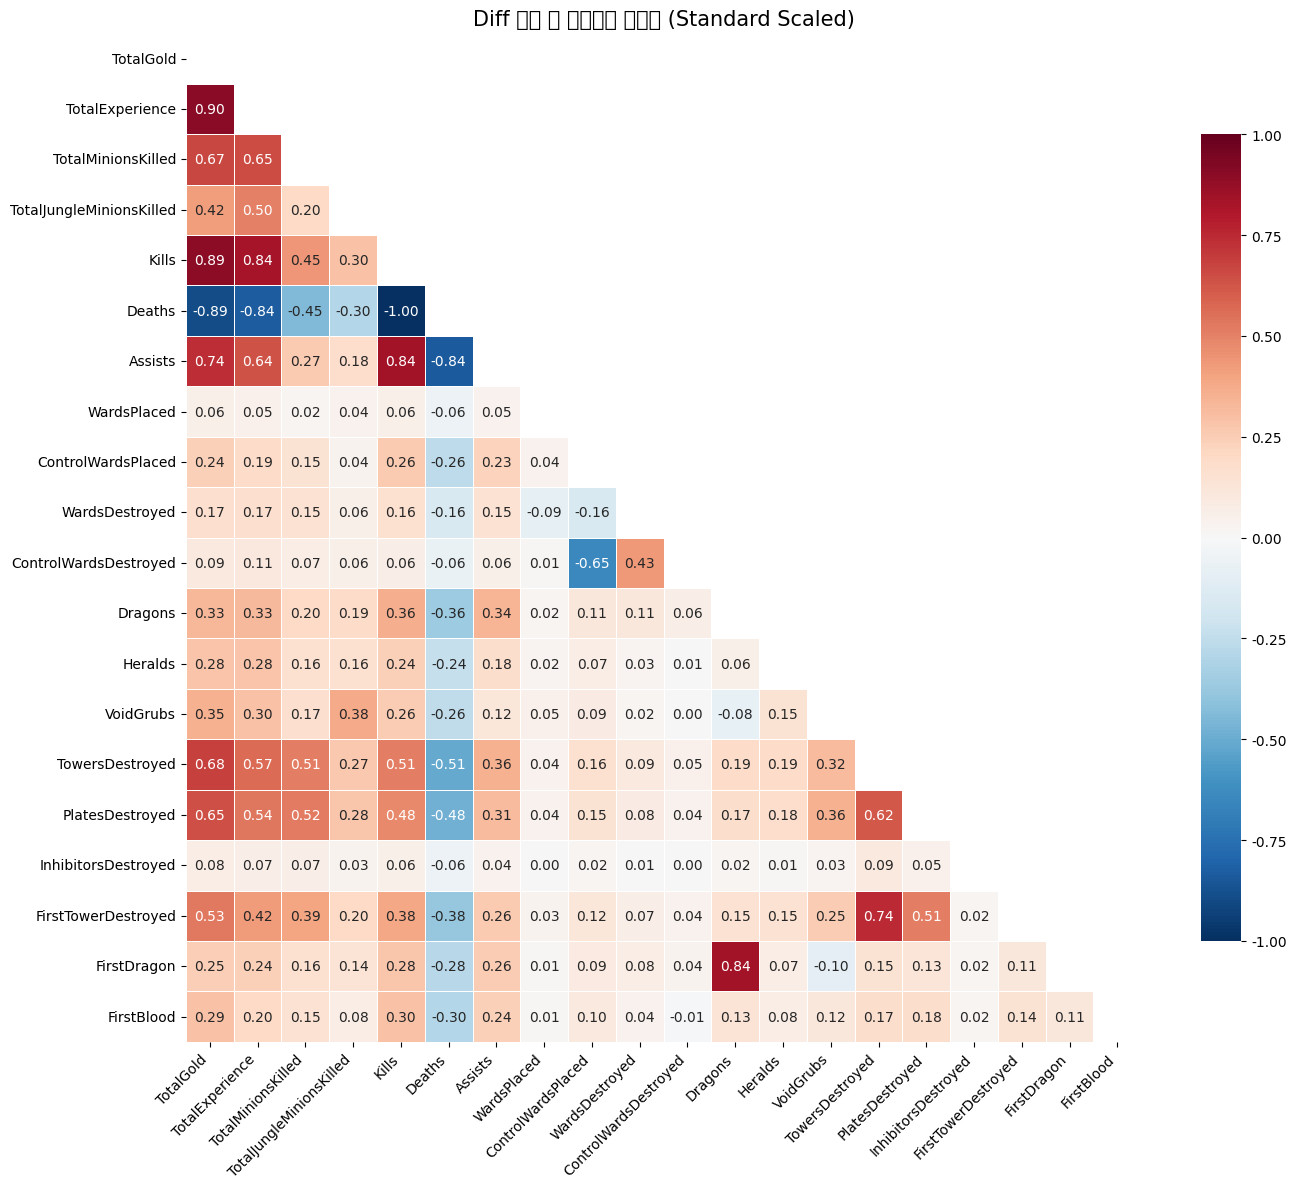

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ======================================================
# 1. 데이터 준비 (Diff 변수 선택)
# ======================================================
# df_final: Diff 변수가 생성된 데이터

# Diff 변수 선택 (df_final에서 Diff_로 시작하는 모든 컬럼)
valid_cols = [col for col in df_final.columns if col.startswith('Diff_')]

X_data = df_final[valid_cols].copy()
print(f"▶ 분석 대상 변수: {len(valid_cols)}개")

# ======================================================
# 2. 데이터 스케일링 (StandardScaler)
# ======================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

# 스케일링된 데이터를 다시 DataFrame으로 변환 (히트맵 그리기 위해)
X_scaled_df = pd.DataFrame(X_scaled, columns=valid_cols)

# ======================================================
# 3. 상관계수 히트맵 시각화
# ======================================================
plt.figure(figsize=(14, 12))

# 상관계수 계산 (스케일링된 데이터 사용)
corr_matrix = X_scaled_df.corr()

# 마스킹 (대각선 위쪽 가리기)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            mask=mask, 
            vmax=1, vmin=-1, center=0, 
            linewidths=.5, cbar_kws={"shrink": .8})

# 축 이름 깔끔하게 정리
clean_labels = [c.replace('Diff_', '') for c in valid_cols] 

plt.xticks(np.arange(len(clean_labels)) + 0.5, clean_labels, rotation=45, ha='right', fontsize=10)
plt.yticks(np.arange(len(clean_labels)) + 0.5, clean_labels, rotation=0, fontsize=10)

plt.title('Diff 변수 간 상관관계 히트맵 (Standard Scaled)', fontsize=15)
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ======================================================
# 1. 데이터 준비 (앞선 단계의 X_scaled 사용)
# ======================================================
# X_scaled: StandardScaler로 정규화된 데이터 (필수)
# diff_cols: Diff 변수 리스트 (컬럼명)

# 변수명 깔끔하게 정리 (Diff_ 제거)
feature_names = [col.replace('Diff_', '') for col in diff_cols]

print(f"▶ PCA 분석 시작 (목표 설명력: 95%)")
print(f"   - 원본 변수 개수: {X_scaled.shape[1]}개")

# ======================================================
# 2. PCA 수행 (n_components=0.95 설정)
# ======================================================
# 0~1 사이 소수를 넣으면 해당 비율만큼의 분산을 설명하는 최소 개수를 자동 선택함
pca = PCA(n_components=0.95) 
X_pca = pca.fit_transform(X_scaled)

# 결과 확인
n_components = pca.n_components_
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"✅ 분석 완료: {n_components}개의 주성분으로 전체 정보의 {cumulative_variance[-1]*100:.2f}% 설명 가능")
print("-" * 60)

# ======================================================
# 4. 주성분 해석 (Loading Matrix Analysis)
# ======================================================
# 각 PC가 어떤 변수들의 조합인지 뜯어보는 과정

loadings = pd.DataFrame(
    pca.components_, 
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(n_components)]
)

pc_interpretation = []

for i in range(n_components):
    pc_name = f'PC{i+1}'
    
    # 해당 PC에 영향력이 큰 변수 Top 3 추출 (절대값 기준)
    sorted_loadings = loadings.loc[pc_name].abs().sort_values(ascending=False)
    top_vars = sorted_loadings.index[:3].tolist()
    
    # 부호 확인 (+: 양의 상관, -: 음의 상관)
    details = []
    for var in top_vars:
        value = loadings.loc[pc_name, var]
        sign = "(+)" if value > 0 else "(-)"
        details.append(f"{var}{sign}")
    
    # 정보 저장
    pc_interpretation.append({
        '주성분': pc_name,
        '설명력(%)': f"{explained_variance[i]*100:.1f}%",
        '누적(%)': f"{cumulative_variance[i]*100:.1f}%",
        '핵심 구성 변수 (Top 3)': ", ".join(details)
    })

# 결과 데이터프레임 생성
interpretation_df = pd.DataFrame(pc_interpretation)

# 표 출력
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
print("\n=== [PCA 결과 해석] 주성분별 구성 요소 분석표 ===")
print(interpretation_df.to_string(index=False))

▶ PCA 분석 시작 (목표 설명력: 95%)
   - 원본 변수 개수: 20개
✅ 분석 완료: 13개의 주성분으로 전체 정보의 95.16% 설명 가능
------------------------------------------------------------

=== [PCA 결과 해석] 주성분별 구성 요소 분석표 ===
 주성분 설명력(%) 누적(%)                                                    핵심 구성 변수 (Top 3)
 PC1  33.4% 33.4%                                   TotalGold(+), Kills(+), Deaths(-)
 PC2   9.4% 42.8%  ControlWardsDestroyed(+), ControlWardsPlaced(-), WardsDestroyed(+)
 PC3   9.2% 52.0%                   FirstDragon(+), Dragons(+), ControlWardsPlaced(+)
 PC4   6.4% 58.4%                  Assists(+), FirstDragon(-), FirstTowerDestroyed(-)
 PC5   5.5% 63.9%           TotalJungleMinionsKilled(+), VoidGrubs(+), WardsPlaced(+)
 PC6   5.0% 68.9% WardsPlaced(+), InhibitorsDestroyed(+), TotalJungleMinionsKilled(-)
 PC7   5.0% 73.9% InhibitorsDestroyed(+), WardsPlaced(-), TotalJungleMinionsKilled(+)
 PC8   4.6% 78.5%                             FirstBlood(+), Heralds(-), VoidGrubs(+)
 PC9   4.4% 83.0%              Heralds(+), F

In [12]:
# ======================================================
# 전처리 완료된 핵심 데이터셋 정의
# ======================================================

# 1. df_final (전처리 완료 데이터)
#    - 생성 위치: Cell 8
#    - 내용: Diff 변수 20개 + blueWins (승패)
#    - 특징: Blue - Red 격차 변수로 재설계 완료

# 2. X_scaled (스케일링 적용 데이터)
#    - 생성 위치: Cell 10
#    - 내용: StandardScaler로 정규화된 Diff 변수
#    - 특징: 평균 0, 표준편차 1로 변환

# 3. X_pca (PCA 차원축소 데이터)
#    - 생성 위치: Cell 11
#    - 내용: PCA(n_components=0.95) 적용
#    - 특징: 95% 설명력 유지하며 차원 축소


In [13]:
# ======================================================
# [Step 1] 데이터 분할 (Train/Test Split)
# ======================================================
from sklearn.model_selection import train_test_split

# 타겟 변수 분리
y = df_final['blueWins']

# 1) Original 데이터 (df_final)
X_original = df_final.drop('blueWins', axis=1)

# 2) Scaled 데이터 (X_scaled) - numpy array를 DataFrame으로 변환
X_scaled_df = pd.DataFrame(X_scaled, columns=X_original.columns)

# 3) PCA 데이터 (X_pca) - numpy array를 DataFrame으로 변환
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

# 데이터 분할 (80:20, stratify=y, random_state=42)
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_original, y, test_size=0.2, stratify=y, random_state=42
)

X_train_scaled, X_test_scaled, _, _ = train_test_split(
    X_scaled_df, y, test_size=0.2, stratify=y, random_state=42
)

X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca_df, y, test_size=0.2, stratify=y, random_state=42
)

# 결과 확인
print("=" * 60)
print("데이터 분할 완료 (Train 80% : Test 20%)")
print("=" * 60)
print(f"Original  - Train: {X_train_orig.shape}, Test: {X_test_orig.shape}")
print(f"Scaled    - Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"PCA       - Train: {X_train_pca.shape}, Test: {X_test_pca.shape}")
print(f"\n승패 비율 (Train): {y_train.value_counts(normalize=True).to_dict()}")
print(f"승패 비율 (Test):  {y_test.value_counts(normalize=True).to_dict()}")

데이터 분할 완료 (Train 80% : Test 20%)
Original  - Train: (75344, 20), Test: (18836, 20)
Scaled    - Train: (75344, 20), Test: (18836, 20)
PCA       - Train: (75344, 13), Test: (18836, 13)

승패 비율 (Train): {0: 0.5364196220004247, 1: 0.4635803779995753}
승패 비율 (Test):  {0: 0.5364196220004247, 1: 0.4635803779995753}


In [14]:
# ======================================================
# [Step 2] 모델 학습 - Logistic Regression (기본 모델)
# ======================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

print("=" * 60)
print("[1/7] Logistic Regression 학습 중...")
print("=" * 60)

# 10-Fold Stratified Cross Validation 설정
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 각 데이터셋별 학습
models_lr = {}

# 1) Original
lr_orig = LogisticRegression(max_iter=1000, random_state=42)
lr_orig.fit(X_train_orig, y_train)
models_lr['Original'] = lr_orig

# 2) Scaled
lr_scaled = LogisticRegression(max_iter=1000, random_state=42)
lr_scaled.fit(X_train_scaled, y_train)
models_lr['Scaled'] = lr_scaled

# 3) PCA
lr_pca = LogisticRegression(max_iter=1000, random_state=42)
lr_pca.fit(X_train_pca, y_train)
models_lr['PCA'] = lr_pca

print("✅ Logistic Regression 학습 완료")

[1/7] Logistic Regression 학습 중...
✅ Logistic Regression 학습 완료


In [15]:
# ======================================================
# [Step 3] 모델 학습 - Ridge Regression (다중공선성 제어)
# ======================================================
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import GridSearchCV

print("=" * 60)
print("[2/7] Ridge Classifier 학습 중 (GridSearchCV)...")
print("=" * 60)

# 하이퍼파라미터 범위 (다중공선성이 심하므로 넓은 범위)
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

models_ridge = {}

# 1) Original
ridge_orig = GridSearchCV(RidgeClassifier(random_state=42), param_grid_ridge, cv=cv, scoring='f1', n_jobs=-1)
ridge_orig.fit(X_train_orig, y_train)
models_ridge['Original'] = ridge_orig.best_estimator_
print(f"Original - Best alpha: {ridge_orig.best_params_['alpha']}, Best F1: {ridge_orig.best_score_:.4f}")

# 2) Scaled
ridge_scaled = GridSearchCV(RidgeClassifier(random_state=42), param_grid_ridge, cv=cv, scoring='f1', n_jobs=-1)
ridge_scaled.fit(X_train_scaled, y_train)
models_ridge['Scaled'] = ridge_scaled.best_estimator_
print(f"Scaled   - Best alpha: {ridge_scaled.best_params_['alpha']}, Best F1: {ridge_scaled.best_score_:.4f}")

# 3) PCA
ridge_pca = GridSearchCV(RidgeClassifier(random_state=42), param_grid_ridge, cv=cv, scoring='f1', n_jobs=-1)
ridge_pca.fit(X_train_pca, y_train)
models_ridge['PCA'] = ridge_pca.best_estimator_
print(f"PCA      - Best alpha: {ridge_pca.best_params_['alpha']}, Best F1: {ridge_pca.best_score_:.4f}")

print("\n✅ Ridge Classifier 학습 완료")

[2/7] Ridge Classifier 학습 중 (GridSearchCV)...
Original - Best alpha: 100, Best F1: 0.7589
Scaled   - Best alpha: 10, Best F1: 0.7589
PCA      - Best alpha: 100, Best F1: 0.7573

✅ Ridge Classifier 학습 완료


In [16]:
# ======================================================
# [Step 4] 모델 학습 - Lasso Regression (다중공선성 제어)
# ======================================================
from sklearn.linear_model import LogisticRegression

print("=" * 60)
print("[3/7] Lasso (L1 Regularization) 학습 중 (GridSearchCV)...")
print("=" * 60)

# 하이퍼파라미터 범위
param_grid_lasso = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}  # C = 1/alpha

models_lasso = {}

# 1) Original
lasso_orig = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    param_grid_lasso, cv=cv, scoring='f1', n_jobs=-1
)
lasso_orig.fit(X_train_orig, y_train)
models_lasso['Original'] = lasso_orig.best_estimator_
print(f"Original - Best C: {lasso_orig.best_params_['C']}, Best F1: {lasso_orig.best_score_:.4f}")

# 2) Scaled
lasso_scaled = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    param_grid_lasso, cv=cv, scoring='f1', n_jobs=-1
)
lasso_scaled.fit(X_train_scaled, y_train)
models_lasso['Scaled'] = lasso_scaled.best_estimator_
print(f"Scaled   - Best C: {lasso_scaled.best_params_['C']}, Best F1: {lasso_scaled.best_score_:.4f}")

# 3) PCA
lasso_pca = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    param_grid_lasso, cv=cv, scoring='f1', n_jobs=-1
)
lasso_pca.fit(X_train_pca, y_train)
models_lasso['PCA'] = lasso_pca.best_estimator_
print(f"PCA      - Best C: {lasso_pca.best_params_['C']}, Best F1: {lasso_pca.best_score_:.4f}")

print("\n✅ Lasso 학습 완료")

[3/7] Lasso (L1 Regularization) 학습 중 (GridSearchCV)...
Original - Best C: 0.001, Best F1: 0.7617
Scaled   - Best C: 0.001, Best F1: 0.7635
PCA      - Best C: 0.001, Best F1: 0.7593

✅ Lasso 학습 완료


In [ ]:
# ======================================================
# [Step 5] 모델 학습 - ElasticNet (다중공선성 제어)
# ======================================================

print("=" * 60)
print("[4/7] ElasticNet 학습 중 (GridSearchCV)...")
print("=" * 60)

# 하이퍼파라미터 범위
param_grid_elastic = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

models_elastic = {}

# 1) Original
elastic_orig = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=2000, random_state=42),
    param_grid_elastic, cv=cv, scoring='f1', n_jobs=-1
)
elastic_orig.fit(X_train_orig, y_train)
models_elastic['Original'] = elastic_orig.best_estimator_
print(f"Original - Best C: {elastic_orig.best_params_['C']}, l1_ratio: {elastic_orig.best_params_['l1_ratio']}, Best F1: {elastic_orig.best_score_:.4f}")

# 2) Scaled
elastic_scaled = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=2000, random_state=42),
    param_grid_elastic, cv=cv, scoring='f1', n_jobs=-1
)
elastic_scaled.fit(X_train_scaled, y_train)
models_elastic['Scaled'] = elastic_scaled.best_estimator_
print(f"Scaled   - Best C: {elastic_scaled.best_params_['C']}, l1_ratio: {elastic_scaled.best_params_['l1_ratio']}, Best F1: {elastic_scaled.best_score_:.4f}")

# 3) PCA
elastic_pca = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=2000, random_state=42),
    param_grid_elastic, cv=cv, scoring='f1', n_jobs=-1
)
elastic_pca.fit(X_train_pca, y_train)
models_elastic['PCA'] = elastic_pca.best_estimator_
print(f"PCA      - Best C: {elastic_pca.best_params_['C']}, l1_ratio: {elastic_pca.best_params_['l1_ratio']}, Best F1: {elastic_pca.best_score_:.4f}")

print("\n✅ ElasticNet 학습 완료")

[4/7] ElasticNet 학습 중 (GridSearchCV)...


In [ ]:
# ======================================================
# [Step 6] 모델 학습 - Random Forest (변수 중요도 산출)
# ======================================================
from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("[5/7] Random Forest 학습 중 (GridSearchCV)...")
print("=" * 60)

# 하이퍼파라미터 범위
param_grid_rf = {
    'n_estimators': [200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

models_rf = {}

# 1) Original
rf_orig = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=cv, scoring='f1', n_jobs=-1
)
rf_orig.fit(X_train_orig, y_train)
models_rf['Original'] = rf_orig.best_estimator_
print(f"Original - Best params: {rf_orig.best_params_}, Best F1: {rf_orig.best_score_:.4f}")

# 2) Scaled
rf_scaled = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=cv, scoring='f1', n_jobs=-1
)
rf_scaled.fit(X_train_scaled, y_train)
models_rf['Scaled'] = rf_scaled.best_estimator_
print(f"Scaled   - Best params: {rf_scaled.best_params_}, Best F1: {rf_scaled.best_score_:.4f}")

# 3) PCA
rf_pca = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=cv, scoring='f1', n_jobs=-1
)
rf_pca.fit(X_train_pca, y_train)
models_rf['PCA'] = rf_pca.best_estimator_
print(f"PCA      - Best params: {rf_pca.best_params_}, Best F1: {rf_pca.best_score_:.4f}")

print("\n✅ Random Forest 학습 완료")

In [ ]:
# ======================================================
# [Step 7] 모델 학습 - XGBoost (변수 중요도 산출)
# ======================================================
import xgboost as xgb

print("=" * 60)
print("[6/7] XGBoost 학습 중 (GridSearchCV)...")
print("=" * 60)

# 하이퍼파라미터 범위
param_grid_xgb = {
    'n_estimators': [200],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

models_xgb = {}

# 1) Original
xgb_orig = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid_xgb, cv=cv, scoring='f1', n_jobs=-1
)
xgb_orig.fit(X_train_orig, y_train)
models_xgb['Original'] = xgb_orig.best_estimator_
print(f"Original - Best params: {xgb_orig.best_params_}, Best F1: {xgb_orig.best_score_:.4f}")

# 2) Scaled
xgb_scaled = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid_xgb, cv=cv, scoring='f1', n_jobs=-1
)
xgb_scaled.fit(X_train_scaled, y_train)
models_xgb['Scaled'] = xgb_scaled.best_estimator_
print(f"Scaled   - Best params: {xgb_scaled.best_params_}, Best F1: {xgb_scaled.best_score_:.4f}")

# 3) PCA
xgb_pca = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid_xgb, cv=cv, scoring='f1', n_jobs=-1
)
xgb_pca.fit(X_train_pca, y_train)
models_xgb['PCA'] = xgb_pca.best_estimator_
print(f"PCA      - Best params: {xgb_pca.best_params_}, Best F1: {xgb_pca.best_score_:.4f}")

print("\n✅ XGBoost 학습 완료")

In [ ]:
# ======================================================
# [Step 8] 모델 성능 평가 및 비교
# ======================================================

print("=" * 60)
print("[7/7] 모델 성능 평가 중...")
print("=" * 60)

# 평가 함수
def evaluate_model(model, X_test, y_test, dataset_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return {
        'Dataset': dataset_name,
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1-Score': f"{f1:.4f}"
    }

# 전체 모델 성능 평가
results_all = []

# Logistic Regression
for dataset_name in ['Original', 'Scaled', 'PCA']:
    X_test = X_test_orig if dataset_name == 'Original' else (X_test_scaled if dataset_name == 'Scaled' else X_test_pca)
    result = evaluate_model(models_lr[dataset_name], X_test, y_test, dataset_name)
    result['Model'] = 'Logistic Regression'
    results_all.append(result)

# Ridge
for dataset_name in ['Original', 'Scaled', 'PCA']:
    X_test = X_test_orig if dataset_name == 'Original' else (X_test_scaled if dataset_name == 'Scaled' else X_test_pca)
    result = evaluate_model(models_ridge[dataset_name], X_test, y_test, dataset_name)
    result['Model'] = 'Ridge'
    results_all.append(result)

# Lasso
for dataset_name in ['Original', 'Scaled', 'PCA']:
    X_test = X_test_orig if dataset_name == 'Original' else (X_test_scaled if dataset_name == 'Scaled' else X_test_pca)
    result = evaluate_model(models_lasso[dataset_name], X_test, y_test, dataset_name)
    result['Model'] = 'Lasso'
    results_all.append(result)

# ElasticNet
for dataset_name in ['Original', 'Scaled', 'PCA']:
    X_test = X_test_orig if dataset_name == 'Original' else (X_test_scaled if dataset_name == 'Scaled' else X_test_pca)
    result = evaluate_model(models_elastic[dataset_name], X_test, y_test, dataset_name)
    result['Model'] = 'ElasticNet'
    results_all.append(result)

# Random Forest
for dataset_name in ['Original', 'Scaled', 'PCA']:
    X_test = X_test_orig if dataset_name == 'Original' else (X_test_scaled if dataset_name == 'Scaled' else X_test_pca)
    result = evaluate_model(models_rf[dataset_name], X_test, y_test, dataset_name)
    result['Model'] = 'Random Forest'
    results_all.append(result)

# XGBoost
for dataset_name in ['Original', 'Scaled', 'PCA']:
    X_test = X_test_orig if dataset_name == 'Original' else (X_test_scaled if dataset_name == 'Scaled' else X_test_pca)
    result = evaluate_model(models_xgb[dataset_name], X_test, y_test, dataset_name)
    result['Model'] = 'XGBoost'
    results_all.append(result)

# DataFrame으로 변환
performance_df = pd.DataFrame(results_all)
performance_df = performance_df[['Model', 'Dataset', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]

print("\n" + "=" * 80)
print("모델 성능 비교표 (Test Set)")
print("=" * 80)
print(performance_df.to_string(index=False))

# 시각화용 변수 저장 (F1-Score 기준 정렬)
# performance_df_viz: 시각화에 사용할 성능 비교 데이터프레임
performance_df['F1_numeric'] = performance_df['F1-Score'].astype(float)
performance_df_viz = performance_df.sort_values('F1_numeric', ascending=False).copy()

# 최고 성능 모델 찾기
best_idx = performance_df['F1_numeric'].idxmax()
best_model_name = performance_df.loc[best_idx, 'Model']
best_dataset_name = performance_df.loc[best_idx, 'Dataset']
best_f1_score = performance_df.loc[best_idx, 'F1-Score']

print("\n" + "=" * 80)
print(f"🏆 최고 성능 모델: {best_model_name} ({best_dataset_name})")
print(f"   F1-Score: {best_f1_score}")
print("=" * 80)

In [ ]:
# ======================================================
# [Step 9] 변수 중요도 추출 (Random Forest & XGBoost - Original 데이터)
# ======================================================

print("=" * 60)
print("변수 중요도 분석 (Original 데이터 기준)")
print("=" * 60)

# Random Forest 변수 중요도 (Top 10)
rf_importances = pd.DataFrame({
    'Feature': X_train_orig.columns,
    'Importance': models_rf['Original'].feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("\n[Random Forest] Top 10 변수 중요도:")
print(rf_importances.to_string(index=False))

# XGBoost 변수 중요도 (Top 10)
xgb_importances = pd.DataFrame({
    'Feature': X_train_orig.columns,
    'Importance': models_xgb['Original'].feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("\n[XGBoost] Top 10 변수 중요도:")
print(xgb_importances.to_string(index=False))

# 시각화용 변수 저장
# rf_importances_viz: Random Forest 변수 중요도 (Top 10)
# xgb_importances_viz: XGBoost 변수 중요도 (Top 10)
rf_importances_viz = rf_importances.copy()
xgb_importances_viz = xgb_importances.copy()

print("\n✅ 변수 중요도 추출 완료 (rf_importances_viz, xgb_importances_viz에 저장)")

In [ ]:
# ======================================================
# [Step 10] 의사결정트리 제작 (T값 상위 5개 변수 사용)
# ======================================================
from sklearn.tree import DecisionTreeClassifier, export_text
from scipy import stats

print("=" * 60)
print("의사결정트리 제작 (T값 상위 5개 변수)")
print("=" * 60)

# T값 기준 변수 선택 (이미 계산된 final_df 활용)
# final_df에서 T-value 절대값 기준 Top 5 추출
top5_vars = final_df.head(5)['변수명 (Variable)'].tolist()
print(f"\n선정된 Top 5 변수: {top5_vars}")

# Top 5 변수로 데이터 필터링
X_train_top5 = X_train_orig[top5_vars]
X_test_top5 = X_test_orig[top5_vars]

# 의사결정트리 학습 (max_depth 제한 없음)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_top5, y_train)

# 성능 평가
y_pred_dt = dt_model.predict(X_test_top5)
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("\n" + "=" * 60)
print("의사결정트리 성능 (Test Set)")
print("=" * 60)
print(f"Accuracy:  {dt_acc:.4f}")
print(f"Precision: {dt_prec:.4f}")
print(f"Recall:    {dt_rec:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")

# 트리 구조 텍스트 출력
print("\n" + "=" * 60)
print("의사결정트리 구조 (텍스트)")
print("=" * 60)
tree_rules = export_text(dt_model, feature_names=top5_vars)
print(tree_rules)

# 시각화용 변수 저장
# dt_model_viz: 의사결정트리 모델 객체
# dt_performance: 의사결정트리 성능 지표
# top5_features: Top 5 변수 리스트
dt_model_viz = dt_model
dt_performance = {
    'Accuracy': dt_acc,
    'Precision': dt_prec,
    'Recall': dt_rec,
    'F1-Score': dt_f1
}
top5_features = top5_vars

print("\n✅ 의사결정트리 제작 완료 (dt_model_viz, dt_performance, top5_features에 저장)")

In [ ]:
# ======================================================
# [Step 11] 실전 검증 - 최고 성능 모델 vs 의사결정트리
# ======================================================

print("=" * 60)
print("실전 검증: 실제 게임 데이터로 모델 비교")
print("=" * 60)

# 실제 경기 데이터 (기존 my_matches 활용)
# my_matches는 이미 위에서 정의됨

# DataFrame 변환
df_real_matches = pd.DataFrame(my_matches)

# 특성 데이터 추출
X_real = df_real_matches[X_original.columns]

# 1) 최고 성능 모델 예측
if best_model_name == 'Logistic Regression':
    best_model = models_lr[best_dataset_name]
elif best_model_name == 'Ridge':
    best_model = models_ridge[best_dataset_name]
elif best_model_name == 'Lasso':
    best_model = models_lasso[best_dataset_name]
elif best_model_name == 'ElasticNet':
    best_model = models_elastic[best_dataset_name]
elif best_model_name == 'Random Forest':
    best_model = models_rf[best_dataset_name]
elif best_model_name == 'XGBoost':
    best_model = models_xgb[best_dataset_name]

# 데이터 변환 (Scaled 또는 PCA인 경우)
if best_dataset_name == 'Scaled':
    # Scaler 재적용
    X_real_transformed = scaler.transform(X_real)
    X_real_transformed = pd.DataFrame(X_real_transformed, columns=X_original.columns)
elif best_dataset_name == 'PCA':
    # Scaler + PCA 재적용
    X_real_scaled = scaler.transform(X_real)
    X_real_transformed = pca.transform(X_real_scaled)
    X_real_transformed = pd.DataFrame(X_real_transformed, columns=[f'PC{i+1}' for i in range(X_real_transformed.shape[1])])
else:
    X_real_transformed = X_real

# 최고 모델 예측
y_pred_best = best_model.predict(X_real_transformed)
y_proba_best = best_model.predict_proba(X_real_transformed)[:, 1]

# 2) 의사결정트리 예측
X_real_top5 = X_real[top5_features]
y_pred_dt_real = dt_model.predict(X_real_top5)
y_proba_dt_real = dt_model.predict_proba(X_real_top5)[:, 1]

# 결과 비교 테이블
comparison_results = []
for i, match in enumerate(my_matches):
    comparison_results.append({
        '경기': match['Match'],
        '실제 결과': 'WIN' if match['blueWins'] == 1 else 'LOSE',
        f'{best_model_name} 예측': 'WIN' if y_pred_best[i] == 1 else 'LOSE',
        f'{best_model_name} 승률': f"{y_proba_best[i]*100:.2f}%",
        'DecisionTree 예측': 'WIN' if y_pred_dt_real[i] == 1 else 'LOSE',
        'DecisionTree 승률': f"{y_proba_dt_real[i]*100:.2f}%"
    })

comparison_df = pd.DataFrame(comparison_results)

print("\n" + "=" * 100)
print("실전 검증 결과")
print("=" * 100)
print(comparison_df.to_string(index=False))

# 정확도 계산
y_true = [m['blueWins'] for m in my_matches]
best_accuracy = accuracy_score(y_true, y_pred_best)
dt_accuracy = accuracy_score(y_true, y_pred_dt_real)

print("\n" + "=" * 100)
print(f"✅ {best_model_name} 정확도: {best_accuracy:.2%} ({sum(y_pred_best == y_true)}/{len(y_true)} 정답)")
print(f"✅ DecisionTree 정확도: {dt_accuracy:.2%} ({sum(y_pred_dt_real == y_true)}/{len(y_true)} 정답)")
print("=" * 100)

# 시각화용 변수 저장
# comparison_df_viz: 실전 검증 비교 결과 데이터프레임
# best_model_info: 최고 모델 정보 (이름, 데이터셋, F1 점수, 실전 정확도)
comparison_df_viz = comparison_df.copy()
best_model_info = {
    'name': best_model_name,
    'dataset': best_dataset_name,
    'f1_score': best_f1_score,
    'real_accuracy': best_accuracy
}

print("\n✅ 실전 검증 완료 (comparison_df_viz, best_model_info에 저장)")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# [데이터 입력] 실제 플레이한 11경기 데이터 하드코딩
my_matches = [
    # Match 01: (승리) 시작부터 전 라인이 압도하여 20분 만에 넥서스를 깬 완승 경기
    {
        "Match": "Match 01", "blueWins": 1,
        "Diff_TotalGold": 9500, "Diff_TotalExperience": 7200, "Diff_Kills": 18, "Diff_Deaths": -18, "Diff_Assists": 25,
        "Diff_WardsPlaced": 8, "Diff_ControlWardsPlaced": 4, "Diff_WardsDestroyed": 5, "Diff_Dragons": 3, "Diff_Heralds": 2, "Diff_VoidGrubs": 4, "Diff_TowersDestroyed": 5, "Diff_PlatesDestroyed": 7,
        "Diff_MinionsKilled": 55, "Diff_JungleMinionsKilled": 22, "Diff_InhibitorsDestroyed": 1, "Diff_FirstTurret": 1, "Diff_FirstDragon": 1, "Diff_FirstBlood": 1
    },

    # Match 02: (패배) 초반 인베이드 사고 후 전 라인이 터져서 15분에 항복한 경기
    {
        "Match": "Match 02", "blueWins": 0,
        "Diff_TotalGold": -8200, "Diff_TotalExperience": -6500, "Diff_Kills": -16, "Diff_Deaths": 16, "Diff_Assists": -12,
        "Diff_WardsPlaced": -6, "Diff_ControlWardsPlaced": -4, "Diff_WardsDestroyed": -3, "Diff_Dragons": -2, "Diff_Heralds": -1, "Diff_VoidGrubs": -3, "Diff_TowersDestroyed": -4, "Diff_PlatesDestroyed": -5,
        "Diff_MinionsKilled": -45, "Diff_JungleMinionsKilled": -18, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0
    },

    # Match 03: (패배) 팽팽하게 잘 싸웠으나, 후반 중요 한타 한 번 패배로 그대로 게임이 끝난 아쉬운 석패
    {
        "Match": "Match 03", "blueWins": 0,
        "Diff_TotalGold": -1200, "Diff_TotalExperience": -800, "Diff_Kills": -2, "Diff_Deaths": 2, "Diff_Assists": -5,
        "Diff_WardsPlaced": 3, "Diff_ControlWardsPlaced": 1, "Diff_WardsDestroyed": 2, "Diff_Dragons": 0, "Diff_Heralds": 0, "Diff_VoidGrubs": -1, "Diff_TowersDestroyed": -1, "Diff_PlatesDestroyed": -1,
        "Diff_MinionsKilled": -5, "Diff_JungleMinionsKilled": -2, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 1, "Diff_FirstBlood": 0
    },

    # Match 04: (승리) 초반에 불리했으나, 상대방이 방심하고 던진 것을 받아먹고 기적적으로 역전한 경기
    {
        "Match": "Match 04", "blueWins": 1,
        "Diff_TotalGold": -3100, "Diff_TotalExperience": -2100, "Diff_Kills": -6, "Diff_Deaths": 6, "Diff_Assists": -9,
        "Diff_WardsPlaced": -2, "Diff_ControlWardsPlaced": -1, "Diff_WardsDestroyed": -1, "Diff_Dragons": 1, "Diff_Heralds": 0, "Diff_VoidGrubs": 0, "Diff_TowersDestroyed": -1, "Diff_PlatesDestroyed": -2,
        "Diff_MinionsKilled": -20, "Diff_JungleMinionsKilled": -5, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0
    },

    # Match 05: (승리) 무리하지 않고 야금야금 이득을 챙겨서 스노우볼을 굴려 안전하게 이긴 경기
    {
        "Match": "Match 05", "blueWins": 1,
        "Diff_TotalGold": 1300, "Diff_TotalExperience": 900, "Diff_Kills": 4, "Diff_Deaths": -4, "Diff_Assists": 6,
        "Diff_WardsPlaced": 1, "Diff_ControlWardsPlaced": 1, "Diff_WardsDestroyed": 0, "Diff_Dragons": 1, "Diff_Heralds": 0, "Diff_VoidGrubs": 1, "Diff_TowersDestroyed": 1, "Diff_PlatesDestroyed": 1,
        "Diff_MinionsKilled": 12, "Diff_JungleMinionsKilled": 2, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 1
    },

    # Match 06: (패배) 우리 정글러가 상대에게 완전히 말려서 성장 차이가 심해 무력하게 진 경기
    {
        "Match": "Match 06", "blueWins": 0,
        "Diff_TotalGold": -5200, "Diff_TotalExperience": -4100, "Diff_Kills": -11, "Diff_Deaths": 11, "Diff_Assists": -9,
        "Diff_WardsPlaced": -5, "Diff_ControlWardsPlaced": -2, "Diff_WardsDestroyed": -2, "Diff_Dragons": -3, "Diff_Heralds": -1, "Diff_VoidGrubs": -2, "Diff_TowersDestroyed": -3, "Diff_PlatesDestroyed": -4,
        "Diff_MinionsKilled": -12, "Diff_JungleMinionsKilled": -28, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0
    },

    # Match 07: (승리) 40분 넘는 장기전 끝에 장로 드래곤 버프를 획득하여 한타를 대승한 혈전
    {
        "Match": "Match 07", "blueWins": 1,
        "Diff_TotalGold": -150, "Diff_TotalExperience": 80, "Diff_Kills": 1, "Diff_Deaths": -1, "Diff_Assists": 1,
        "Diff_WardsPlaced": 2, "Diff_ControlWardsPlaced": 0, "Diff_WardsDestroyed": 1, "Diff_Dragons": 0, "Diff_Heralds": 0, "Diff_VoidGrubs": 0, "Diff_TowersDestroyed": 0, "Diff_PlatesDestroyed": 0,
        "Diff_MinionsKilled": 6, "Diff_JungleMinionsKilled": -3, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 1, "Diff_FirstDragon": 0, "Diff_FirstBlood": 1
    },

    # Match 08: (패배) 싸움(킬)은 이겼으나, 상대가 교전을 피하고 타워만 밀어서 운영에 휘둘리다 진 경기
    {
        "Match": "Match 08", "blueWins": 0,
        "Diff_TotalGold": -2100, "Diff_TotalExperience": -1600, "Diff_Kills": 5, "Diff_Deaths": -5, "Diff_Assists": 2,
        "Diff_WardsPlaced": -4, "Diff_ControlWardsPlaced": -1, "Diff_WardsDestroyed": -1, "Diff_Dragons": -1, "Diff_Heralds": 0, "Diff_VoidGrubs": -1, "Diff_TowersDestroyed": -4, "Diff_PlatesDestroyed": -2,
        "Diff_MinionsKilled": -22, "Diff_JungleMinionsKilled": -6, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 1, "Diff_FirstBlood": 0
    },

    # Match 09: (승리) 우리 팀 탑 라이너가 괴물같이 성장해서 혼자 다 죽이고 캐리한 경기 (버스 탑승)
    {
        "Match": "Match 09", "blueWins": 1,
        "Diff_TotalGold": 4600, "Diff_TotalExperience": 4100, "Diff_Kills": 9, "Diff_Deaths": -9, "Diff_Assists": 7,
        "Diff_WardsPlaced": 4, "Diff_ControlWardsPlaced": 3, "Diff_WardsDestroyed": 2, "Diff_Dragons": 1, "Diff_Heralds": 1, "Diff_VoidGrubs": 3, "Diff_TowersDestroyed": 4, "Diff_PlatesDestroyed": 5,
        "Diff_MinionsKilled": 42, "Diff_JungleMinionsKilled": 11, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 1, "Diff_FirstDragon": 1, "Diff_FirstBlood": 1
    },

    # Match 10: (패배) 초반 라인전 단계에서 게임이 터져 팀원들이 의욕을 잃고 '미드 오픈' 한 경기
    {
        "Match": "Match 10", "blueWins": 0,
        "Diff_TotalGold": -7200, "Diff_TotalExperience": -5600, "Diff_Kills": -13, "Diff_Deaths": 13, "Diff_Assists": -16,
        "Diff_WardsPlaced": -7, "Diff_ControlWardsPlaced": -3, "Diff_WardsDestroyed": -4, "Diff_Dragons": -2, "Diff_Heralds": -1, "Diff_VoidGrubs": -3, "Diff_TowersDestroyed": -5, "Diff_PlatesDestroyed": -6,
        "Diff_MinionsKilled": -38, "Diff_JungleMinionsKilled": -12, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0
    },

    # Match 11: (승리) 킬 스코어는 밀렸지만, 사이드 운영으로 CS와 골드를 더 챙겨 '돈의 힘'으로 찍어 누른 경기
    {
        "Match": "Match 11", "blueWins": 1,
        "Diff_TotalGold": 2610, "Diff_TotalExperience": -2726, "Diff_Kills": -3, "Diff_Deaths": 3, "Diff_Assists": -5,
        "Diff_WardsPlaced": -2, "Diff_ControlWardsPlaced": 0, "Diff_WardsDestroyed": 0, "Diff_Dragons": -1, "Diff_Heralds": 0, "Diff_VoidGrubs": 1, "Diff_TowersDestroyed": -1, "Diff_PlatesDestroyed": 0,
        "Diff_MinionsKilled": 35, "Diff_JungleMinionsKilled": 10, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 1
    }
]

# 2. DataFrame 변환 및 모델 예측
df_graph = pd.DataFrame(my_matches)
feature_names = X.columns.tolist()

# 예측을 위한 데이터 준비
X_graph = df_graph[feature_names]

# [수정] 앙상블 제거: 오직 XGBoost 모델(best_xgb)만 사용
# (DNN을 위해 사용했던 scaler, pca 등 불필요한 과정은 생략)
p_xgb = best_xgb.predict_proba(X_graph)[:, 1]

# 소수점 둘째 자리까지 반올림
df_graph['Win_Prob'] = (p_xgb * 100).round(2)
df_graph['Result_Str'] = df_graph['blueWins'].apply(lambda x: 'WIN' if x == 1 else 'LOSE')

# 3. 시각화
plt.figure(figsize=(12, 7))

# 색상: WIN=파랑, LOSE=빨강
colors = ['dodgerblue' if x == 1 else 'salmon' for x in df_graph['blueWins']]
bars = plt.barh(df_graph['Match'], df_graph['Win_Prob'], color=colors, edgecolor='black', alpha=0.9)

# 기준선 표시
plt.axvline(30, color='red', linestyle='--', linewidth=1.5, label='Surrender Zone (30%)')
plt.axvline(70, color='blue', linestyle='--', linewidth=1.5, label='Victory Zone (70%)')
plt.axvspan(30, 70, color='gray', alpha=0.1, label='Comeback Zone')

# 그래프 꾸미기
plt.xlabel('XGBoost Predicted Win Probability (%)', fontsize=12, fontweight='bold')
plt.title('My Recent Match History Analysis (XGBoost Only)', fontsize=15, fontweight='bold')
plt.gca().invert_yaxis() # Match 1이 위로 오도록 정렬

# 바 끝에 수치 및 결과 표시
for rect, prob, res in zip(bars, df_graph['Win_Prob'], df_graph['Result_Str']):
    width = rect.get_width()
    label_text = f" {prob}% ({res})"
    plt.text(width + 0.5, rect.get_y() + rect.get_height()/2, label_text, 
             va='center', fontsize=10, fontweight='bold', color='black')

plt.xlim(0, 105) # 텍스트 잘림 방지
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# 1. 테이블에 들어갈 데이터 포맷팅 (df_graph는 이전 코드에서 생성된 데이터프레임)
cell_text = []
for index, row in df_graph.iterrows():
    match_name = row['Match']
    gold_diff = f"{row['Diff_TotalGold']:+,}" # 예: +9,500
    kill_diff = f"{row['Diff_Kills']:+}"      # 예: +18
    result = row['Result_Str']                # WIN / LOSE
    
    # 승률 (소수점 2자리)
    win_prob = f"{row['Win_Prob']:.2f}%"
    
    # AI 판정 로직 (30% 미만, 30~70%, 70% 이상)
    prob_val = row['Win_Prob']
    if prob_val >= 70:
        decision = "승리 유력"
    elif prob_val <= 30:
        decision = "항복 권장"
    else:
        decision = "역전승 가능 구간"
        
    cell_text.append([match_name, gold_diff, kill_diff, result, win_prob, decision])

# 2. 테이블 시각화 설정
plt.figure(figsize=(10, 6)) # 표 크기 조절
plt.axis('off') # 축 숨기기

# 컬럼 이름 설정
col_labels = ['경기', '골드 격차', '킬 격차', '결과', '예측 승률', 'AI 판정']

# 테이블 그리기
table = plt.table(cellText=cell_text,
                  colLabels=col_labels,
                  loc='center',
                  cellLoc='center')

# 3. 스타일 꾸미기
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2) # (가로, 세로) 크기 배율 조절

# 헤더와 셀 색상 입히기
for (row, col), cell in table.get_celld().items():
    if row == 0: # 헤더(제목) 행
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#333333')
    else:
        # 결과에 따른 배경색 구분 (WIN: 파랑, LOSE: 빨강)
        result_str = cell_text[row-1][3] # '결과' 컬럼 값 확인
        if result_str == 'WIN':
            cell.set_facecolor('#E6F4FF') # 연한 파랑
        else:
            cell.set_facecolor('#FFE6E6') # 연한 빨강

plt.title("실제 경기 데이터 분석 요약 (XGBoost)", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()